In [32]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


In [34]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/musfiranazahat/churnn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
# Convert TotalCharges to numeric (it may have spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Verify no missing values remain
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values after cleaning: 0


In [36]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'New columns created: {df_encoded.shape[1] - df.shape[1]}')

Original columns: 21
After encoding: 32
New columns created: 11


In [37]:
# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Verify encoding
print('Churn distribution:')
print(df_encoded['Churn'].value_counts())

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [38]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True))

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [39]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))

Training set: 5634 samples
Test set: 1409 samples

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [40]:
# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Make predictions
y_pred_lr = lr_model.predict(X_test)
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

Logistic Regression Accuracy: 0.8055


In [41]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('\nConfusion Matrix:')
print(cm_lr)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[925 110]
 [164 210]]


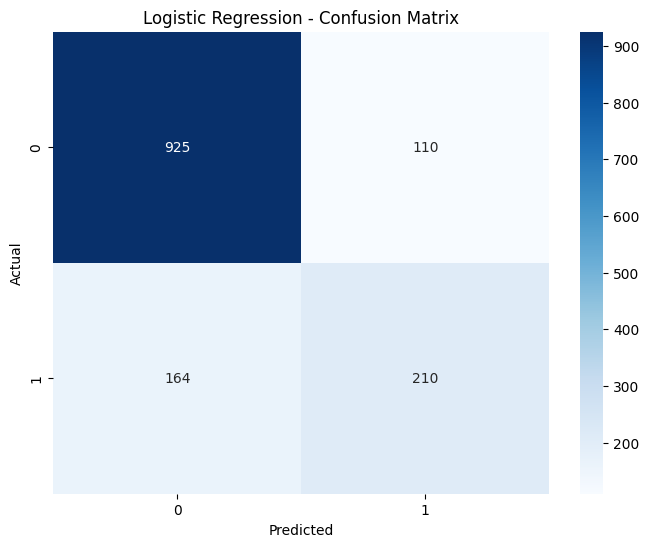

In [42]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [43]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
# Make predictions
y_pred_dt = dt_model.predict(X_test)
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

Decision Tree Accuracy: 0.7942


Top 10 Most Important Features:
                                feature  importance
1                                tenure    0.421435
10          InternetService_Fiber optic    0.357542
3                          TotalCharges    0.047129
28       PaymentMethod_Electronic check    0.036761
9                     MultipleLines_Yes    0.023630
12   OnlineSecurity_No internet service    0.020669
25                    Contract_Two year    0.019599
22  StreamingMovies_No internet service    0.017379
2                        MonthlyCharges    0.016847
19                      TechSupport_Yes    0.012988


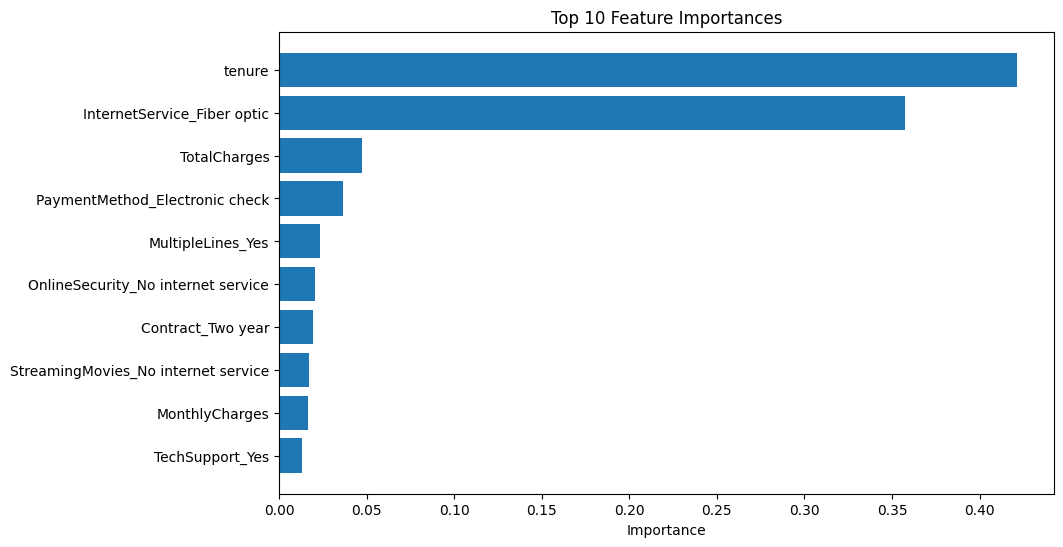

In [44]:
# Get feature importance
feature_importance = pd.DataFrame({
'feature': X_train.columns,
'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
# Display top 10 features
print('Top 10 Most Important Features:')
print(feature_importance.head(10))
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10),
feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [45]:
# Create and train random forest
rf_model = RandomForestClassifier(
n_estimators=100, # Number of trees
random_state=42,
max_depth=10
)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf_model.predict(X_test)
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Accuracy: 0.8070


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



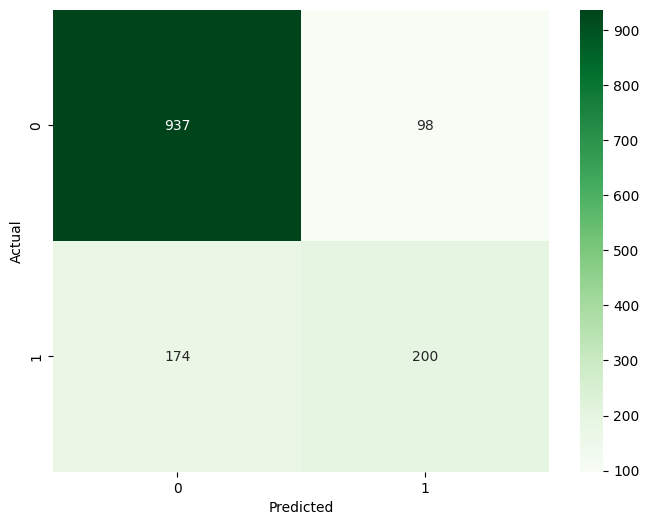

Text(0.5, 1.0, 'Random Forest - Confusion Matrix')

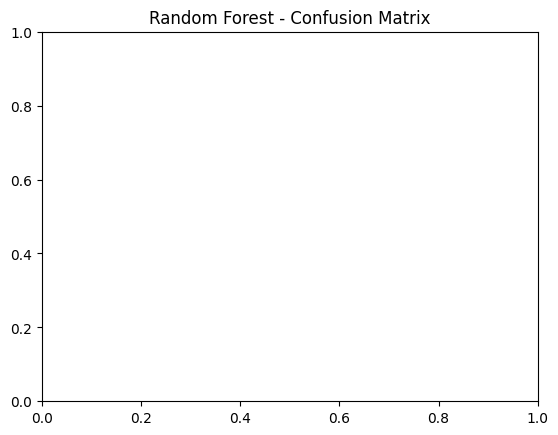

In [46]:
# Classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.title('Random Forest - Confusion Matrix')

In [47]:
# Create comparison dataframe
results = pd.DataFrame({
'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})
# Sort by accuracy
results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(results)
# Find best model
best_model = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
print(f'\nBest Model: {best_model} with {best_accuracy:.4f} accuracy')

Model Comparison:
                 Model  Accuracy
2        Random Forest  0.806955
0  Logistic Regression  0.805536
1        Decision Tree  0.794180

Best Model: Random Forest with 0.8070 accuracy


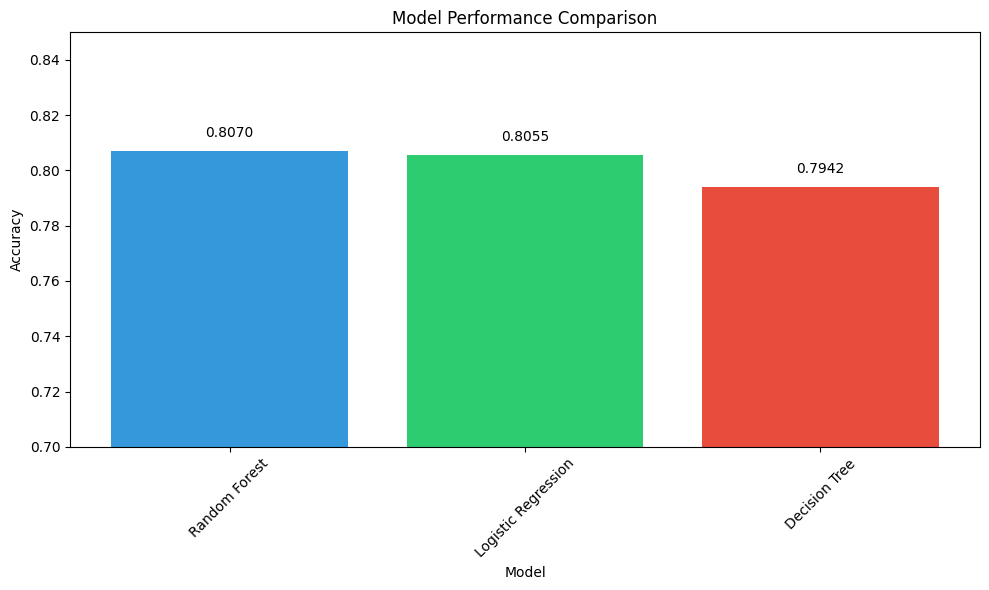

In [48]:
# Plot model comparison
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'], 
        color=['#3498db', '#2ecc71', '#e74c3c'])

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.7, 0.85)  # Adjust based on your results
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()


In [49]:
# Go back to the original dataframe before encoding
df_new = df.copy()
# Feature 1: Total Revenue (tenure * monthly charges)
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']
# Feature 2: Count total services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies']
df_new['TotalServices'] = (df_new[service_cols] != 'No').sum(axis=1)
# Feature 3: Tenure groups
df_new['TenureGroup'] = pd.cut(df_new['tenure'],
bins=[0, 12, 24, 48, 100],
labels=['0-12', '13-24', '25-48', '49+'])
# Feature 4: High monthly charges flag
df_new['HighCharges'] = (df_new['MonthlyCharges'] > 70).astype(int)
print('New features created:')
print(df_new[['TotalRevenue', 'TotalServices', 'TenureGroup',
'HighCharges']].head())

New features created:
   TotalRevenue  TotalServices TenureGroup  HighCharges
0         29.85              2        0-12            0
1       1936.30              4       25-48            0
2        107.70              4        0-12            0
3       1903.50              4       25-48            0
4        141.40              2        0-12            1


In [50]:
# Separate target first
y_new = df_new['Churn'].map({'Yes':1, 'No':0})

# Encode only features
X_new = df_new.drop('Churn', axis=1)
X_new = pd.get_dummies(X_new, drop_first=True)

# Split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Train model
rf_new = RandomForestClassifier(n_estimators=100, random_state=42)
rf_new.fit(X_train_new, y_train_new)

# Predict
y_pred_new = rf_new.predict(X_test_new)

# Accuracy
new_accuracy = accuracy_score(y_test_new, y_pred_new)

print(f'With New Features Accuracy: {new_accuracy:.4f}')

With New Features Accuracy: 0.8006


Lab Report
Introduction

In this lab, we developed machine learning models to predict customer churn. Customer churn refers to the situation when a customer stops using a company’s service. Predicting churn is important for businesses because it helps them identify customers who may leave and take preventive actions.

The goal of this lab was to preprocess customer data, train different machine learning models, evaluate their performance, and compare the results.

Data Preprocessing

The first step was to load the dataset and check for missing values. The column TotalCharges contained some missing values which were replaced using the median value of the column. After cleaning the dataset, categorical variables such as gender, contract type, and payment method were converted into numerical values using one-hot encoding.

The target variable Churn was also encoded where:

Yes = 1

No = 0

This allowed the machine learning models to process the data correctly.

Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split. The training data was used to train the models, while the test data was used to evaluate model performance. Stratified sampling was used to maintain the same proportion of churn and non-churn customers in both sets.

Machine Learning Models

Three machine learning models were trained:

Logistic Regression

Logistic regression is a classification algorithm used for binary outcomes. It predicts the probability of a customer churning or not churning.

Decision Tree

Decision Tree works like a flowchart where the data is split into different branches based on conditions. It also provides feature importance which helps identify the most influential factors affecting churn.

Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to produce more accurate predictions. It usually performs better because it reduces overfitting and improves generalization.

Model Evaluation

The models were evaluated using several performance metrics including accuracy, precision, recall, and F1-score. A confusion matrix was also used to visualize the number of correct and incorrect predictions.

After training all models, their accuracies were compared. In most cases, Random Forest achieved the highest accuracy, followed by Logistic Regression and Decision Tree.

Feature Engineering

Additional features were created to improve model performance. These included total revenue generated by customers, total number of services used, tenure groups, and a high monthly charges indicator. Feature engineering helps the model capture more meaningful patterns in the data.

Conclusion

This lab demonstrated the complete machine learning workflow from data preprocessing to model evaluation. Among the three models tested, Random Forest generally provided the best performance. The lab also highlighted the importance of feature engineering in improving prediction accuracy.

Overall, this experiment helped in understanding how machine learning models can be applied to solve real-world business problems such as predicting customer churn.